# 第3讲：优化与随机梯度下降

本 notebook 对应 CS231n Lecture 3 的内容，涵盖损失函数的优化、梯度下降、SGD 及其变体。

**学习路径：** 直觉理解 $	o$ 手动计算 $	o$ 代码实现 $	o$ 实验观察

**前置知识：** 线性分类器（Lecture 2）、微积分基础、NumPy 基础


## 1. 优化问题简介

### 1.1 什么是优化

在上一讲中，我们定义了损失函数 $L(W)$ 来衡量参数 $W$ 的好坏。**优化** 就是找到使损失最小的参数 $W^*$：

$$W^* = \arg\min_W L(W)$$

其中 $L(W)$ 包含数据损失和正则化项：

$$L(W) = \frac{1}{N} \sum_{i=1}^{N} L_i(W) + \lambda R(W)$$

**为什么优化很难？**
- $L(W)$ 是高维的（参数可能百万级）
- $L(W)$ 是非凸的（对神经网络而言）
- 梯度计算可能昂贵
- 需要选择合适的学习率
- 容易陷入局部最优或鞍点


### 1.2 损失地貌 (Loss Landscape)

我们可以将损失函数想象成一个高维的**地形**（landscape）：
- **山谷** = 低损失区域（好的解）
- **山峰** = 高损失区域
- **梯度** = 地形的坡度，指向上升最快的方向
- **负梯度** = 下降最快的方向

**梯度下降** 就是沿着负梯度方向走，直到到达谷底。

**一维直觉：** 在 1D 中，梯度就是导数。如果 $f'(x) > 0$，函数在增加，我们应该往左走（减小 x）。


In [4]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 12
np.random.seed(42)
print("Libraries loaded successfully!")


Libraries loaded successfully!


Visualization saved as loss_landscape.png


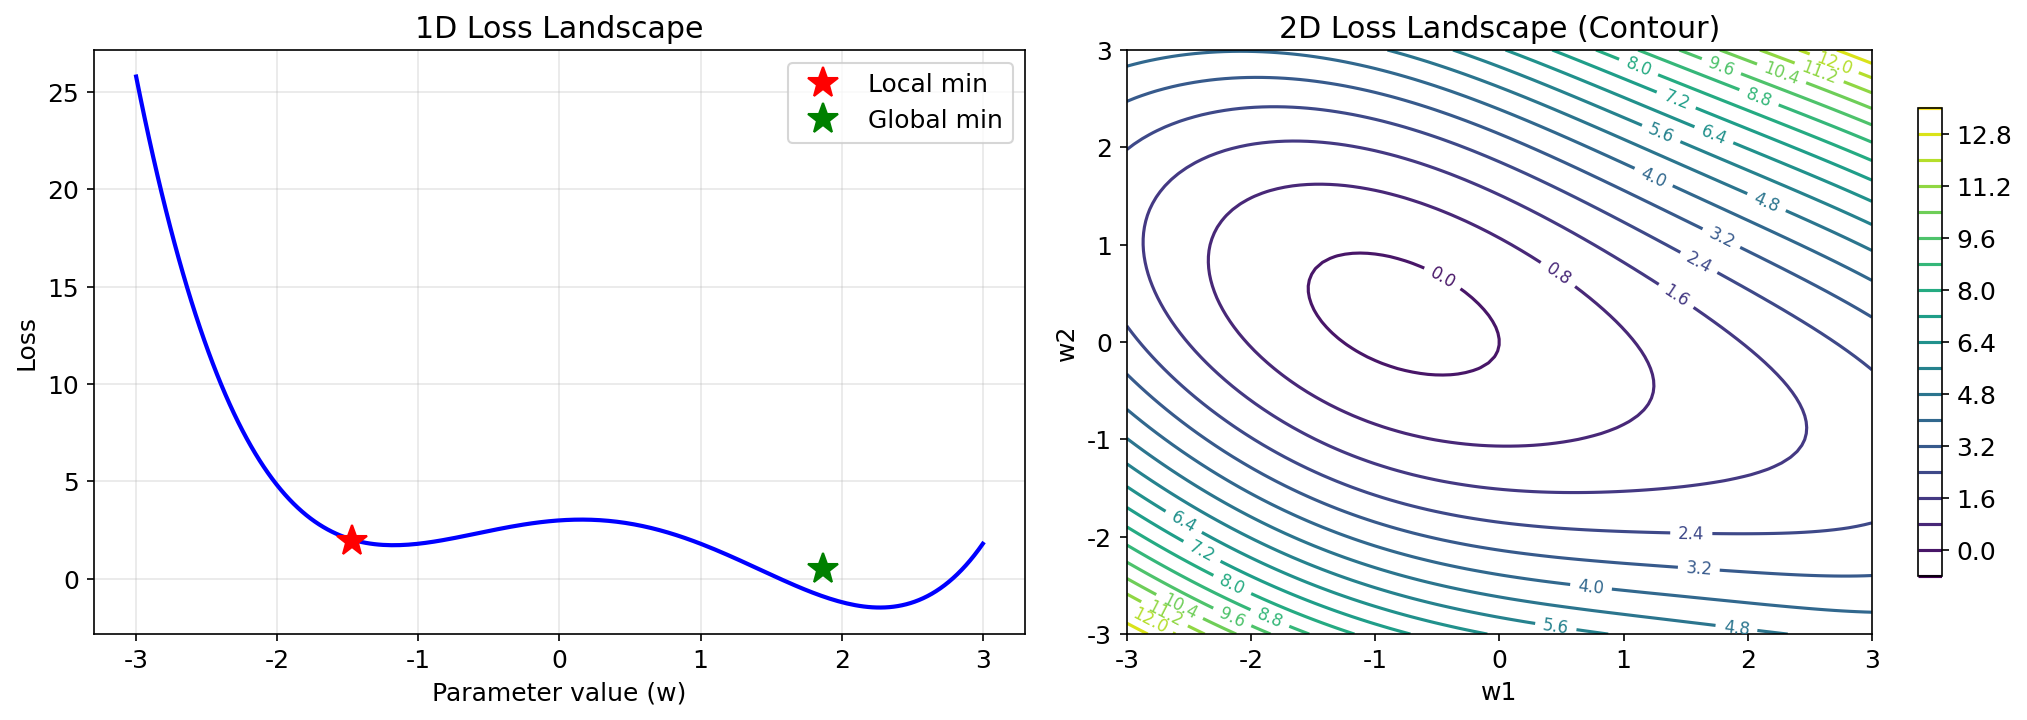

In [5]:
# Visualize loss landscape in 1D and 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1D loss landscape
x = np.linspace(-3, 3, 200)
y_1d = 0.3 * x**4 - 0.5 * x**3 - 1.5 * x**2 + 0.5 * x + 3
axes[0].plot(x, y_1d, 'b-', linewidth=2)
axes[0].set_xlabel('Parameter value (w)')
axes[0].set_ylabel('Loss')
axes[0].set_title('1D Loss Landscape')
axes[0].grid(True, alpha=0.3)

# Mark local and global minima
axes[0].plot([-1.47], [1.95], 'r*', markersize=15, label='Local min')
axes[0].plot([1.87], [0.52], 'g*', markersize=15, label='Global min')
axes[0].legend()

# 2D loss landscape
w1 = np.linspace(-3, 3, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)
Y_2d = 0.3 * W1**2 + 0.7 * W2**2 + 0.5 * W1 * W2 + np.sin(W1) * 0.5

contour = axes[1].contour(W1, W2, Y_2d, levels=20, cmap='viridis')
axes[1].clabel(contour, inline=True, fontsize=8)
axes[1].set_xlabel('w1')
axes[1].set_ylabel('w2')
axes[1].set_title('2D Loss Landscape (Contour)')
fig.colorbar(contour, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig('loss_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as loss_landscape.png")


## 2. 梯度下降 (Gradient Descent)

### 2.1 基本算法

**梯度下降** 是最基本的优化算法：

$$W_{t+1} = W_t - \eta \cdot \nabla_W L(W_t)$$

其中：
- $\eta$ 是学习率 (learning rate)
- $\nabla_W L(W_t)$ 是损失对参数的梯度
- 负号表示沿梯度反方向移动

**算法流程：**
1. 初始化参数 $W_0$
2. 计算梯度 $g = \nabla_W L(W_t)$
3. 更新参数 $W_{t+1} = W_t - \eta g$
4. 重复 2-3 直到收敛

**关键超参数：** 学习率 $\eta$，通常范围 $10^{-5}$ 到 $10^0$


### 2.2 手动计算梯度下降

**目标函数：** $f(w) = w^2 + 2w + 1 = (w+1)^2$

**解析梯度：** $f'(w) = 2w + 2$

**梯度下降：** $\eta = 0.1$, $w_0 = 3$

- $t=0$: $w_0 = 3$, $f'(3) = 8$, $w_1 = 3 - 0.1 \times 8 = 2.2$
- $t=1$: $w_1 = 2.2$, $f'(2.2) = 6.4$, $w_2 = 2.2 - 0.1 \times 6.4 = 1.56$
- $t=2$: $w_2 = 1.56$, $f'(1.56) = 5.12$, $w_3 = 1.56 - 0.1 \times 5.12 = 1.048$
- ...
- $t=\infty$: $w \to -1$ (最优解)

**收敛速度：** 每步减小约 $1 - \eta \cdot 2 = 0.8$ 倍，呈几何级数衰减。


In [8]:
# Basic gradient descent implementation
def gradient_descent(f, df, x0, lr=0.1, n_iters=100):
    """
    Basic gradient descent
    Args:
        f: objective function
        df: gradient function
        x0: initial point
        lr: learning rate
        n_iters: number of iterations
    Returns:
        history: list of (x, f(x)) at each step
    """
    x = x0
    history = [(x, f(x))]
    for i in range(n_iters):
        grad = df(x)
        x = x - lr * grad
        history.append((x, f(x)))
    return history

# Test with f(w) = w^2 + 2w + 1
f = lambda w: w**2 + 2*w + 1
df = lambda w: 2*w + 2

history = gradient_descent(f, df, x0=3.0, lr=0.1, n_iters=20)
print("Manual calculation verification:")
for i, (w, fv) in enumerate(history[:6]):
    print(f"  t={i}: w={w:.4f}, f(w)={fv:.4f}")
print(f"  Final: w={history[-1][0]:.6f}, optimal=-1.0")


Manual calculation verification:
  t=0: w=3.0000, f(w)=16.0000
  t=1: w=2.2000, f(w)=10.2400
  t=2: w=1.5600, f(w)=6.5536
  t=3: w=1.0480, f(w)=4.1943
  t=4: w=0.6384, f(w)=2.6844
  t=5: w=0.3107, f(w)=1.7180
  Final: w=-0.953883, optimal=-1.0


Visualization saved as gradient_descent_1d.png


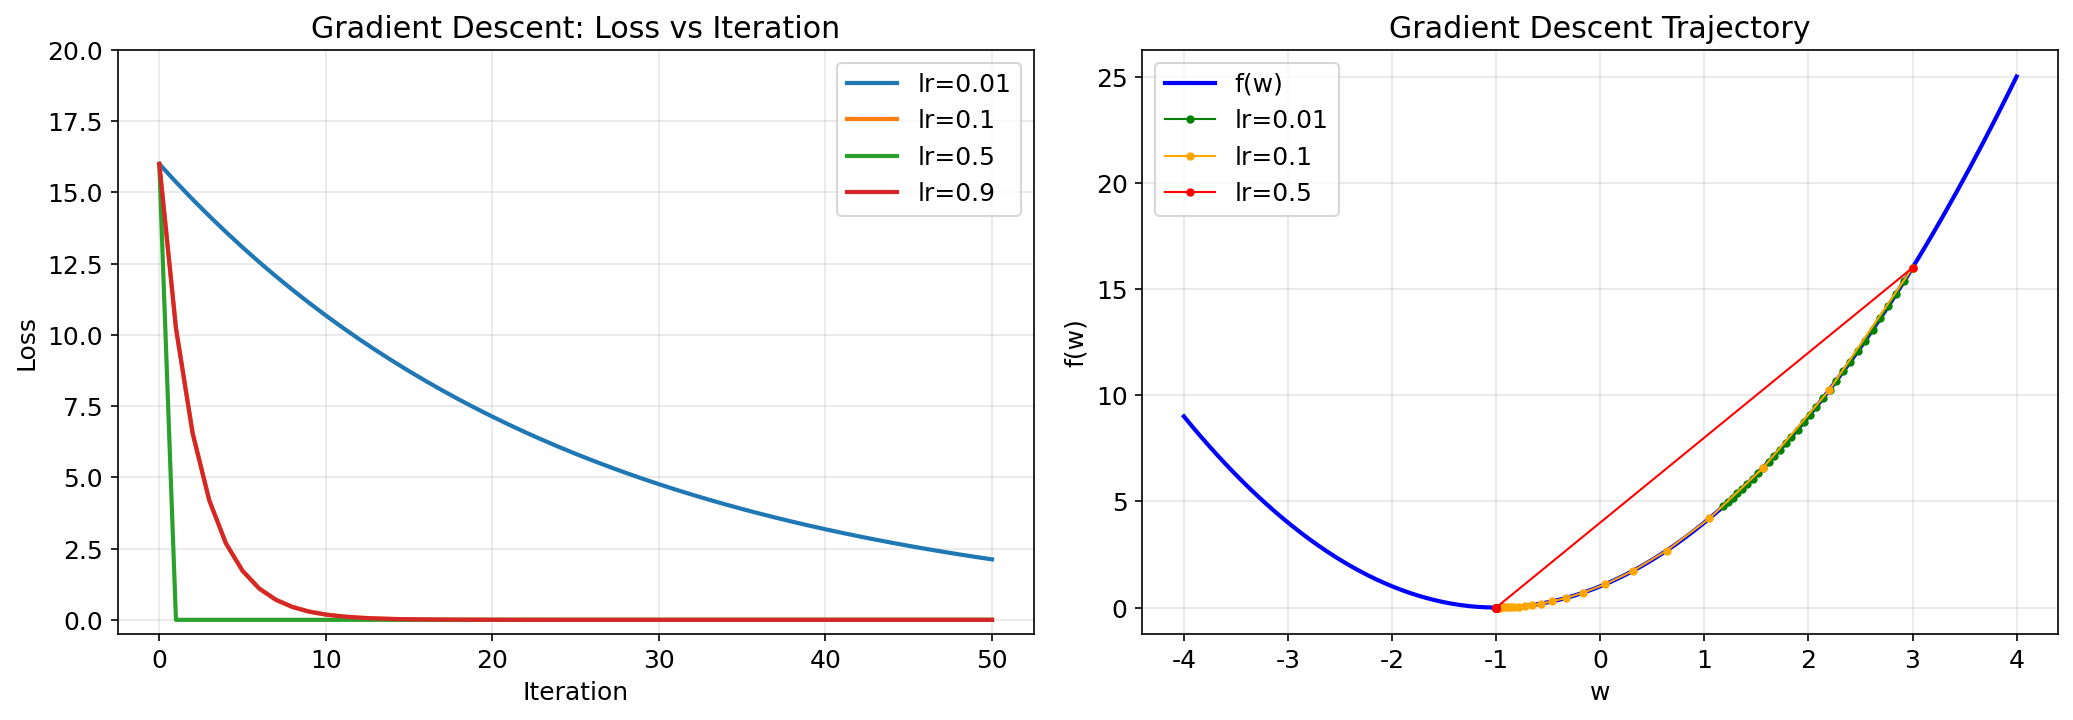

In [9]:
# Visualize gradient descent on 1D function
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Different learning rates
lrs = [0.01, 0.1, 0.5, 0.9]
x_range = np.linspace(-4, 4, 200)
y_range = [f(x) for x in x_range]

for lr in lrs:
    hist = gradient_descent(f, df, x0=3.0, lr=lr, n_iters=50)
    ws = [h[0] for h in hist]
    fs = [h[1] for h in hist]
    axes[0].plot(range(len(fs)), fs, linewidth=2, label=f'lr={lr}')

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Gradient Descent: Loss vs Iteration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.5, 20)

# Show trajectory on function
axes[1].plot(x_range, y_range, 'b-', linewidth=2, label='f(w)')
for lr, color in zip([0.01, 0.1, 0.5], ['green', 'orange', 'red']):
    hist = gradient_descent(f, df, x0=3.0, lr=lr, n_iters=30)
    ws = [h[0] for h in hist]
    fs = [h[1] for h in hist]
    axes[1].plot(ws, fs, 'o-', markersize=3, linewidth=1, color=color, label=f'lr={lr}')

axes[1].set_xlabel('w')
axes[1].set_ylabel('f(w)')
axes[1].set_title('Gradient Descent Trajectory')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_descent_1d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as gradient_descent_1d.png")


### 2.3 学习率的影响

学习率是梯度下降中最重要的超参数：

- **太小** ($\eta = 0.01$)：收敛太慢，需要大量迭代
- **适中** ($\eta = 0.1$)：快速稳定收敛
- **太大** ($\eta = 0.5$)：振荡，收敛慢
- **过大** ($\eta > 1.0$)：发散，损失增大

**经验法则：** 从较大学习率开始，逐步减小。或使用自适应学习率方法。


## 3. 随机梯度下降 (Stochastic Gradient Descent, SGD)

### 3.1 动机

**问题：** 当训练集很大（如 ImageNet 有 130 万张图像）时，每次迭代计算全部数据的梯度太昂贵。

$$\nabla_W L(W) = \frac{1}{N} \sum_{i=1}^{N} \nabla_W L_i(W) + \lambda \nabla R(W)$$

计算全部 $N$ 个样本的梯度，每次更新都要遍历整个数据集。

**解决方案：** 每次只使用一个（或少量）样本估计梯度。

### 3.2 SGD 算法

**SGD：** 每次随机选一个样本 $i$，用 $\nabla_W L_i(W)$ 近似完整梯度：

$$W_{t+1} = W_t - \eta \cdot \nabla_W L_i(W_t)$$

**Mini-batch SGD：** 每次使用一小批样本（batch size 通常 32-256）：

$$W_{t+1} = W_t - \eta \cdot \frac{1}{B} \sum_{j \in B} \nabla_W L_j(W_t)$$

**优势：**
- 每次更新快得多
- 引入随机性，有助于逃离局部最优
- 在大数据集上高效


### 3.3 手动计算 SGD

**目标函数：** $L(w) = \frac{1}{4}\sum_{i=1}^{4}(w x_i - y_i)^2$

数据：$X = [1, 2, 3, 4]$, $Y = [2, 4, 6, 8]$（即 $y = 2x$）

**完整梯度：** $\nabla L = \frac{1}{4}\sum_{i} 2(wx_i - y_i)x_i$

**SGD：** 每次随机选一个样本。假设选 $i=1$（$x_1=1, y_1=2$）：

- $w_0 = 0$, $\nabla = 2(0 \cdot 1 - 2) \cdot 1 = -4$
- $w_1 = 0 - 0.1 \times (-4) = 0.4$

如果选 $i=4$（$x_4=4, y_4=8$）：
- $w_0 = 0$, $\nabla = 2(0 \cdot 4 - 8) \cdot 4 = -64$
- $w_1 = 0 - 0.01 \times (-64) = 0.64$

**注意：** 不同样本的梯度差异很大，这就是 SGD 噪声的来源。


batch_size=1: final loss=0.0041
batch_size=16: final loss=1.9526
batch_size=32: final loss=1.3637
batch_size=200: final loss=12.2750
Visualization saved as sgd_batch_size.png


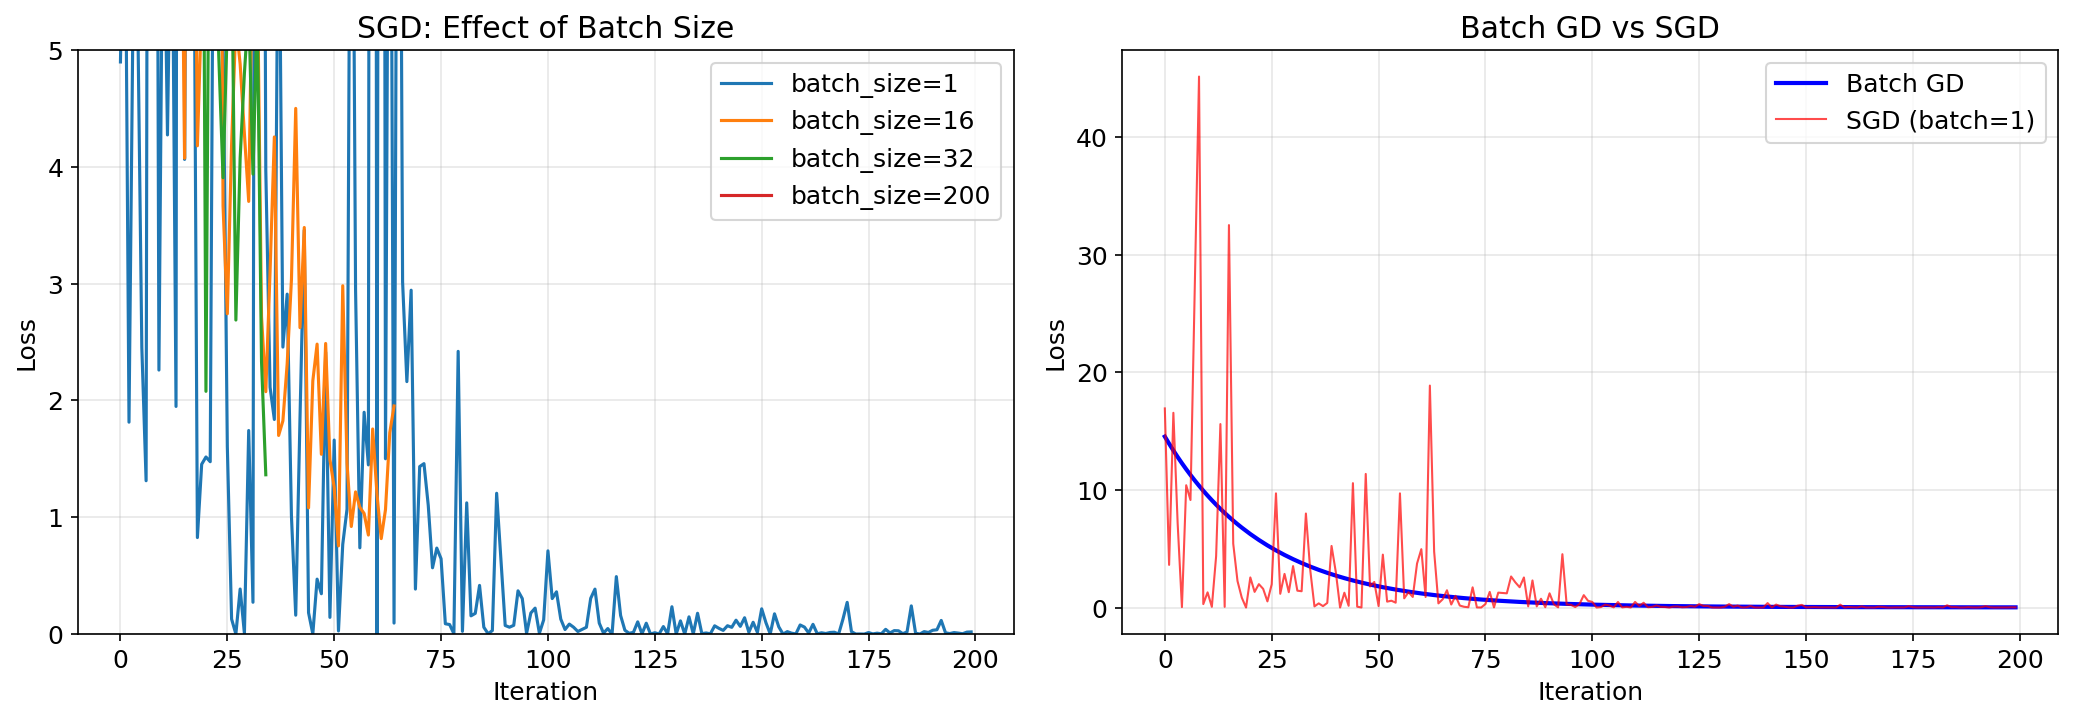

In [13]:
# SGD implementation
def sgd_update(w, dw, lr):
    """Standard SGD update"""
    return w - lr * dw

def minibatch_sgd(X, y, w_init, lr=0.01, batch_size=32, n_epochs=10):
    """
    Mini-batch SGD
    Args:
        X: (N, D) data
        y: (N,) labels
        w_init: initial weights
        lr: learning rate
        batch_size: mini-batch size
        n_epochs: number of epochs
    Returns:
        w: final weights
        loss_history: list of losses
    """
    N = X.shape[0]
    w = w_init.copy()
    loss_history = []
    
    for epoch in range(n_epochs):
        # Shuffle data
        indices = np.random.permutation(N)
        
        for start in range(0, N, batch_size):
            batch_idx = indices[start:start+batch_size]
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]
            
            # Compute loss and gradient (simple linear regression)
            predictions = X_batch @ w
            errors = predictions - y_batch
            loss = np.mean(errors ** 2)
            grad = 2 * X_batch.T @ errors / len(batch_idx)
            
            # SGD update
            w = sgd_update(w, grad, lr)
            loss_history.append(loss)
    
    return w, loss_history

# Generate linear regression data
np.random.seed(42)
N = 200
X_reg = np.random.randn(N, 3)
true_w = np.array([1.0, -2.0, 3.0])
y_reg = X_reg @ true_w + 0.1 * np.random.randn(N)

# Train with different batch sizes
batch_sizes = [1, 16, 32, 200]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for bs in batch_sizes:
    w_init = np.zeros(3)
    w_final, losses = minibatch_sgd(X_reg, y_reg, w_init, lr=0.01, batch_size=bs, n_epochs=5)
    axes[0].plot(losses[:200], linewidth=1.5, label=f'batch_size={bs}')
    print(f"batch_size={bs}: final loss={losses[-1]:.4f}")

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('SGD: Effect of Batch Size')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 5)

# Full gradient descent for comparison
w_gd = np.zeros(3)
gd_losses = []
for epoch in range(5):
    for i in range(200):  # same total iterations as 1 epoch of batch_size=1
        predictions = X_reg @ w_gd
        errors = predictions - y_reg
        loss = np.mean(errors ** 2)
        grad = 2 * X_reg.T @ errors / N
        w_gd = sgd_update(w_gd, grad, 0.01)
        gd_losses.append(loss)

axes[1].plot(gd_losses[:200], 'b-', linewidth=2, label='Batch GD')
w_init = np.zeros(3)
w_final, sgd_losses = minibatch_sgd(X_reg, y_reg, w_init, lr=0.01, batch_size=1, n_epochs=1)
axes[1].plot(sgd_losses[:200], 'r-', linewidth=1, alpha=0.7, label='SGD (batch=1)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].set_title('Batch GD vs SGD')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_batch_size.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as sgd_batch_size.png")


## 4. 动量方法 (Momentum)

### 4.1 动机

**SGD 的问题：**
- 在 loss landscape 的"峡谷"中（一个方向陡峭，另一个方向平缓），SGD 会剧烈振荡
- 学习率必须设得很小才能避免发散，导致收敛慢

**解决思路：** 累积历史梯度信息，平滑振荡，加速收敛。

### 4.2 动量法

**标准动量 (Polyak, 1964):**

$$v_t = \mu v_{t-1} - \eta \nabla L(W_t)$$
$$W_{t+1} = W_t + v_t$$

其中 $\mu$ 是动量系数（通常 0.9），$v$ 是速度。

**Nesterov 动量 (NAG):**

$$v_t = \mu v_{t-1} - \eta \nabla L(W_t + \mu v_{t-1})$$
$$W_{t+1} = W_t + v_t$$

NAG 在"前瞻"位置计算梯度，通常效果更好。


### 4.3 手动计算动量

**目标：** $f(w) = w^2$, 最优 $w^* = 0$

**参数：** $\eta = 0.1$, $\mu = 0.9$, $w_0 = 3$

| t | $w_t$ | $\nabla f = 2w$ | $v_t = 0.9 v_{t-1} - 0.1 \nabla$ | $w_{t+1}$ |
|---|--------|-----------------|----------------------------------|-----------|
| 0 | 3.0    | 6.0             | 0 - 0.6 = -0.6                   | 2.4       |
| 1 | 2.4    | 4.8             | -0.54 - 0.48 = -1.02             | 1.38      |
| 2 | 1.38   | 2.76            | -0.918 - 0.276 = -1.194          | 0.186     |
| 3 | 0.186  | 0.372           | -1.075 - 0.037 = -1.112          | -0.926    |

**对比 SGD：** 同样 $\eta=0.1$
- $t=1$: $w=3-0.3=2.7$
- $t=2$: $w=2.7-0.27=2.43$

动量法在第 2 步已经到 1.38，SGD 还在 2.43，加速效果明显！


In [16]:
# Momentum optimizer
def sgd_momentum(w, dw, v, lr=0.01, momentum=0.9):
    """
    SGD with momentum
    """
    v = momentum * v - lr * dw
    w = w + v
    return w, v

def nesterov_momentum(w, dw, v, lr=0.01, momentum=0.9):
    """
    Nesterov Accelerated Gradient
    """
    v_prev = v.copy()
    v = momentum * v - lr * dw
    w = w - momentum * v_prev + (1 + momentum) * v
    return w, v

# Compare SGD, Momentum, and Nesterov on a quadratic function
# f(w) = w^2 (1D), gradient = 2w
def compare_optimizers_1d(lr=0.1, n_iters=50):
    results = {}
    
    # Standard SGD
    w = 3.0
    sgd_path = [w]
    for _ in range(n_iters):
        grad = 2 * w
        w = w - lr * grad
        sgd_path.append(w)
    results['SGD'] = sgd_path
    
    # Momentum
    w = 3.0
    v = 0.0
    mom_path = [w]
    for _ in range(n_iters):
        grad = 2 * w
        w, v = sgd_momentum(w, grad, v, lr=lr, momentum=0.9)
        mom_path.append(w)
    results['Momentum'] = mom_path
    
    # Nesterov
    w = 3.0
    v = 0.0
    nes_path = [w]
    for _ in range(n_iters):
        grad = 2 * w
        w, v = nesterov_momentum(w, grad, v, lr=lr, momentum=0.9)
        nes_path.append(w)
    results['Nesterov'] = nes_path
    
    return results

results = compare_optimizers_1d(lr=0.1, n_iters=30)
print("Optimization of f(w) = w^2, w0=3.0")
for name, path in results.items():
    print(f"  {name}: w_final={path[-1]:.6f}")


AttributeError: 'float' object has no attribute 'copy'

In [17]:
# Visualize optimizer comparison on 1D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
for name, path in results.items():
    losses = [w**2 for w in path]
    axes[0].plot(range(len(losses)), losses, linewidth=2, label=name)

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss (w^2)')
axes[0].set_title('Loss vs Iteration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.5, 10)

# Parameter trajectories
for name, path in results.items():
    axes[1].plot(range(len(path)), path, linewidth=2, label=name)

axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('w')
axes[1].set_title('Parameter Trajectory')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison_1d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as optimizer_comparison_1d.png")


NameError: name 'results' is not defined

## 5. 自适应学习率方法

### 5.1 动机

不同参数可能需要不同的学习率。频繁更新的参数可能需要较小的学习率，不频繁更新的参数可能需要较大的学习率。

### 5.2 AdaGrad (2011)

**核心思想：** 根据历史梯度平方和自适应调整学习率。

$$G_t = G_{t-1} + g_t \odot g_t$$
$$W_{t+1} = W_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \odot g_t$$

**特点：** 学习率单调递减，可能过早停止。

### 5.3 RMSprop

**改进：** 使用指数加权移动平均代替累积求和。

$$G_t = \beta G_{t-1} + (1-\beta) g_t^2$$
$$W_{t+1} = W_t - \frac{\eta}{\sqrt{G_t + \epsilon}} g_t$$

**特点：** 学习率不会过早衰减到 0。

### 5.4 Adam (2014)

**结合动量和自适应学习率：**

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$  (一阶矩)
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$  (二阶矩)
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}$$  (偏差修正)
$$\hat{v}_t = \frac{v_t}{1-\beta_2^t}$$  (偏差修正)
$$W_{t+1} = W_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

**默认参数：** $\beta_1=0.9, \beta_2=0.999, \epsilon=10^{-8}$


In [19]:
# Implement all optimizers
class Optimizer:
    """Base optimizer class"""
    def __init__(self, lr=0.01):
        self.lr = lr
    
    def update(self, w, grad, state):
        raise NotImplementedError

class SGDOptimizer(Optimizer):
    def update(self, w, grad, state):
        return w - self.lr * grad, state

class MomentumOptimizer(Optimizer):
    def __init__(self, lr=0.01, momentum=0.9):
        super().__init__(lr)
        self.momentum = momentum
    
    def update(self, w, grad, state):
        v = state.get('v', np.zeros_like(w))
        v = self.momentum * v - self.lr * grad
        return w + v, {'v': v}

class RMSpropOptimizer(Optimizer):
    def __init__(self, lr=0.01, beta=0.99, eps=1e-8):
        super().__init__(lr)
        self.beta = beta
        self.eps = eps
    
    def update(self, w, grad, state):
        cache = state.get('cache', np.zeros_like(w))
        cache = self.beta * cache + (1 - self.beta) * grad**2
        w = w - self.lr * grad / (np.sqrt(cache) + self.eps)
        return w, {'cache': cache}

class AdamOptimizer(Optimizer):
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
    
    def update(self, w, grad, state):
        m = state.get('m', np.zeros_like(w))
        v = state.get('v', np.zeros_like(w))
        t = state.get('t', 0)
        
        t += 1
        m = self.beta1 * m + (1 - self.beta1) * grad
        v = self.beta2 * v + (1 - self.beta2) * grad**2
        
        m_hat = m / (1 - self.beta1**t)
        v_hat = v / (1 - self.beta2**t)
        
        w = w - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
        return w, {'m': m, 'v': v, 't': t}

print("All optimizers implemented!")


All optimizers implemented!


In [20]:
# Test optimizers on quadratic function
# f(w1, w2) = 10*w1^2 + w2^2  (ill-conditioned: one direction much steeper)
def f_quadratic(w):
    return 10 * w[0]**2 + w[1]**2

def grad_quadratic(w):
    return np.array([20 * w[0], 2 * w[1]])

# Run optimization
optimizers = {
    'SGD': SGDOptimizer(lr=0.01),
    'Momentum': MomentumOptimizer(lr=0.01, momentum=0.9),
    'RMSprop': RMSpropOptimizer(lr=0.1),
    'Adam': AdamOptimizer(lr=0.1),
}

n_iters = 100
paths = {}
for name, opt in optimizers.items():
    w = np.array([3.0, 3.0])
    state = {}
    path = [w.copy()]
    for _ in range(n_iters):
        grad = grad_quadratic(w)
        w, state = opt.update(w, grad, state)
        path.append(w.copy())
    paths[name] = np.array(path)
    print(f"{name}: final w={w}, loss={f_quadratic(w):.6f}")


SGD: final w=[6.11110793e-10 3.97858668e-01], loss=0.158292
Momentum: final w=[-0.00855423  0.01268434], loss=0.000893
RMSprop: final w=[2.5000087e-16 2.5000111e-16], loss=0.000000
Adam: final w=[0.01934456 0.01934456], loss=0.004116


Visualization saved as optimizer_comparison_2d.png


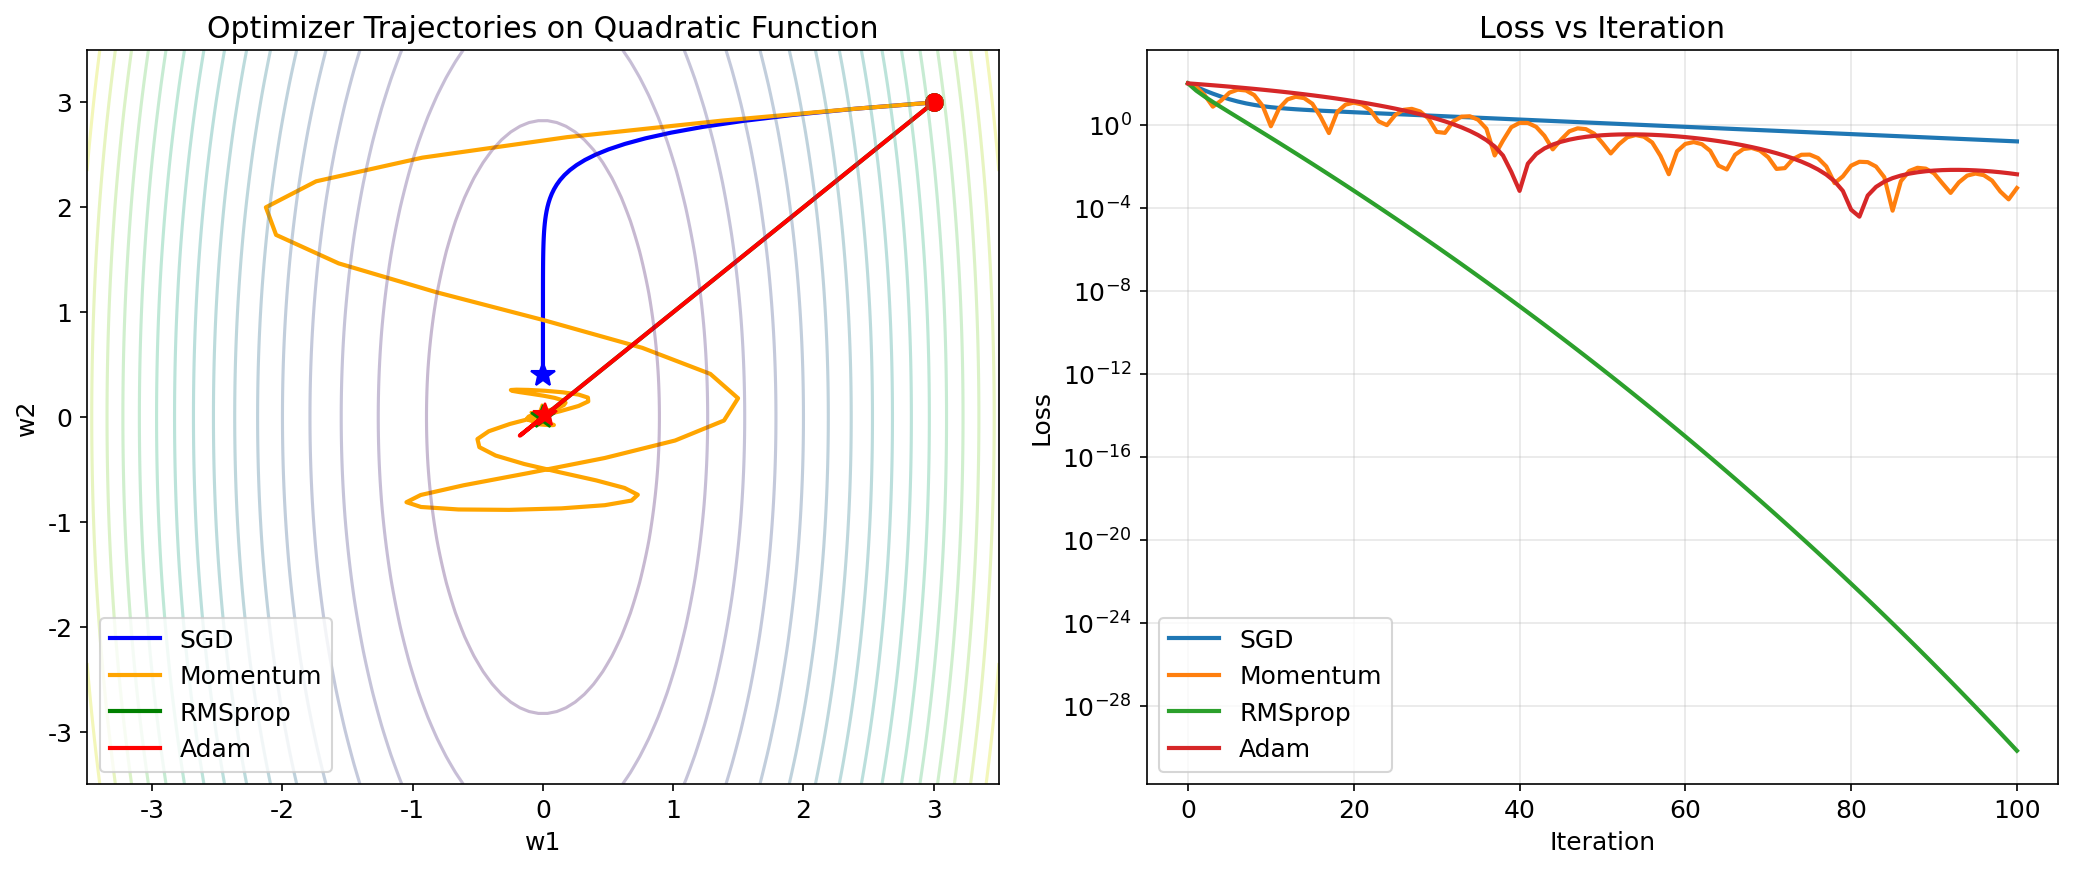

In [21]:
# Visualize optimizer comparison on 2D contour
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Contour plot with trajectories
w1_range = np.linspace(-3.5, 3.5, 100)
w2_range = np.linspace(-3.5, 3.5, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = 10 * W1**2 + W2**2

colors = {'SGD': 'blue', 'Momentum': 'orange', 'RMSprop': 'green', 'Adam': 'red'}

for name, path in paths.items():
    axes[0].plot(path[:, 0], path[:, 1], '-', linewidth=2, label=name, color=colors[name])
    axes[0].plot(path[0, 0], path[0, 1], 'o', color=colors[name], markersize=8)
    axes[0].plot(path[-1, 0], path[-1, 1], '*', color=colors[name], markersize=12)

axes[0].contour(W1, W2, Z, levels=20, cmap='viridis', alpha=0.3)
axes[0].set_xlabel('w1')
axes[0].set_ylabel('w2')
axes[0].set_title('Optimizer Trajectories on Quadratic Function')
axes[0].legend()
axes[0].set_xlim(-3.5, 3.5)
axes[0].set_ylim(-3.5, 3.5)

# Loss curves
for name, path in paths.items():
    losses = [f_quadratic(w) for w in path]
    axes[1].plot(range(len(losses)), losses, linewidth=2, label=name)

axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Iteration')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('optimizer_comparison_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as optimizer_comparison_2d.png")


## 6. 学习率调度 (Learning Rate Scheduling)

### 6.1 为什么需要学习率调度

**训练过程中调整学习率：**
- **初期**：大学习率快速接近最优区域
- **后期**：小学习率精细调整，避免振荡

### 6.2 常见调度策略

**Step decay:** 每 $N$ 步乘以衰减因子
$$\eta_t = \eta_0 \cdot \gamma^{\lfloor t/N \rfloor}$$

**Exponential decay:** 指数衰减
$$\eta_t = \eta_0 \cdot e^{-\lambda t}$$

**Cosine annealing:** 余弦退火
$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_0 - \eta_{min})(1 + \cos(\pi t / T))$$

**Warmup + decay:** 先线性增长再衰减


Visualization saved as learning_rate_schedules.png


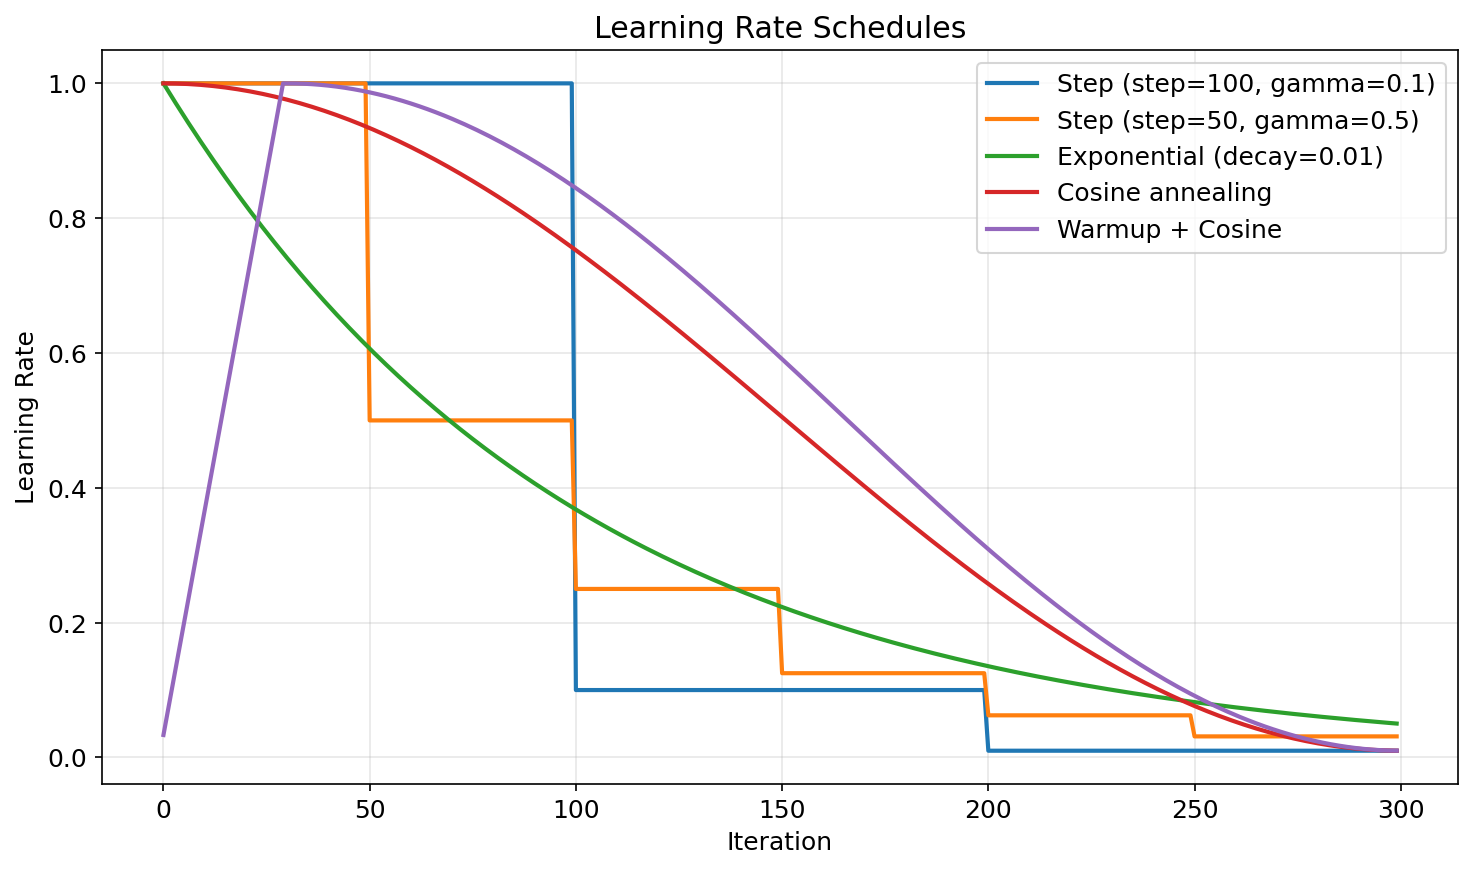

In [23]:
# Learning rate schedules
def step_lr(initial_lr, step_size, gamma, max_iters):
    """Step decay schedule"""
    lrs = []
    for t in range(max_iters):
        lrs.append(initial_lr * (gamma ** (t // step_size)))
    return lrs

def exponential_lr(initial_lr, decay_rate, max_iters):
    """Exponential decay schedule"""
    return [initial_lr * np.exp(-decay_rate * t) for t in range(max_iters)]

def cosine_lr(initial_lr, min_lr, T_max, max_iters):
    """Cosine annealing schedule"""
    lrs = []
    for t in range(max_iters):
        lr = min_lr + 0.5 * (initial_lr - min_lr) * (1 + np.cos(np.pi * t / T_max))
        lrs.append(lr)
    return lrs

def warmup_cosine_lr(initial_lr, min_lr, warmup_iters, T_max, max_iters):
    """Warmup + cosine schedule"""
    lrs = []
    for t in range(max_iters):
        if t < warmup_iters:
            lr = initial_lr * (t + 1) / warmup_iters
        else:
            lr = min_lr + 0.5 * (initial_lr - min_lr) * (1 + np.cos(np.pi * (t - warmup_iters) / (T_max - warmup_iters)))
        lrs.append(lr)
    return lrs

# Visualize schedules
max_iters = 300
schedules = {
    'Step (step=100, gamma=0.1)': step_lr(1.0, 100, 0.1, max_iters),
    'Step (step=50, gamma=0.5)': step_lr(1.0, 50, 0.5, max_iters),
    'Exponential (decay=0.01)': exponential_lr(1.0, 0.01, max_iters),
    'Cosine annealing': cosine_lr(1.0, 0.01, max_iters, max_iters),
    'Warmup + Cosine': warmup_cosine_lr(1.0, 0.01, 30, max_iters, max_iters),
}

plt.figure(figsize=(10, 6))
for name, lrs in schedules.items():
    plt.plot(range(max_iters), lrs, linewidth=2, label=name)

plt.xlabel('Iteration')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedules')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_rate_schedules.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as learning_rate_schedules.png")


## 7. 完整的训练流程

将优化器应用于实际的分类任务：

**训练循环：**
1. 前向传播：计算得分和损失
2. 反向传播：计算梯度
3. 更新参数：用优化器更新
4. 学习率调度：调整学习率
5. 重复


In [25]:
# Complete training with different optimizers
def train_classifier(X, y, X_val, y_val, optimizer, n_classes, 
                     n_epochs=50, batch_size=32, lr_schedule=None):
    """
    Train a linear classifier with given optimizer
    """
    N, D = X.shape
    W = np.random.randn(D, n_classes) * 0.01
    state = {}
    
    train_losses = []
    val_accs = []
    
    for epoch in range(n_epochs):
        # Learning rate for this epoch
        if lr_schedule is not None:
            optimizer.lr = lr_schedule[epoch]
        
        # Shuffle and create mini-batches
        indices = np.random.permutation(N)
        epoch_losses = []
        
        for start in range(0, N, batch_size):
            batch_idx = indices[start:start+batch_size]
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]
            B = len(batch_idx)
            
            # Forward pass (Softmax)
            scores = X_batch @ W
            shifted = scores - np.max(scores, axis=1, keepdims=True)
            exp_scores = np.exp(shifted)
            probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
            
            # Loss
            correct_logprobs = -np.log(probs[np.arange(B), y_batch])
            loss = np.sum(correct_logprobs) / B
            epoch_losses.append(loss)
            
            # Backward pass
            dscores = probs.copy()
            dscores[np.arange(B), y_batch] -= 1
            dscores /= B
            dW = X_batch.T @ dscores
            
            # Update
            W, state = optimizer.update(W, dW, state)
        
        train_losses.append(np.mean(epoch_losses))
        
        # Validation accuracy
        val_scores = X_val @ W
        val_pred = np.argmax(val_scores, axis=1)
        val_accs.append(np.mean(val_pred == y_val))
    
    return W, train_losses, val_accs

# Generate synthetic dataset
np.random.seed(42)
N_train, N_val = 300, 100
D = 4
C = 3

centers = np.array([[2, 2, 0, 0], [-2, 2, 0, 0], [0, -2, 0, 0]])
X_train_c = np.vstack([np.random.randn(N_train//C, D) * 0.5 + centers[i] for i in range(C)])
y_train_c = np.hstack([np.full(N_train//C, i) for i in range(C)])
X_val_c = np.vstack([np.random.randn(N_val//C, D) * 0.5 + centers[i] for i in range(C)])
y_val_c = np.hstack([np.full(N_val//C, i) for i in range(C)])

# Add bias
X_train_c = np.hstack([X_train_c, np.ones((N_train, 1))])
X_val_c = np.hstack([X_val_c, np.ones((N_val, 1))])

print(f"Training data: {X_train_c.shape}")
print(f"Validation data: {X_val_c.shape}")


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 99 and the array at index 1 has size 100

In [26]:
# Train with different optimizers
optimizers_config = {
    'SGD': SGDOptimizer(lr=0.1),
    'Momentum': MomentumOptimizer(lr=0.1, momentum=0.9),
    'RMSprop': RMSpropOptimizer(lr=0.01),
    'Adam': AdamOptimizer(lr=0.01),
}

results = {}
for name, opt in optimizers_config.items():
    np.random.seed(42)
    W, losses, accs = train_classifier(
        X_train_c, y_train_c, X_val_c, y_val_c, opt, C,
        n_epochs=30, batch_size=32
    )
    results[name] = {'losses': losses, 'accs': accs}
    print(f"{name}: final loss={losses[-1]:.4f}, best val acc={max(accs):.4f}")


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 4)

Visualization saved as optimizer_training_comparison.png


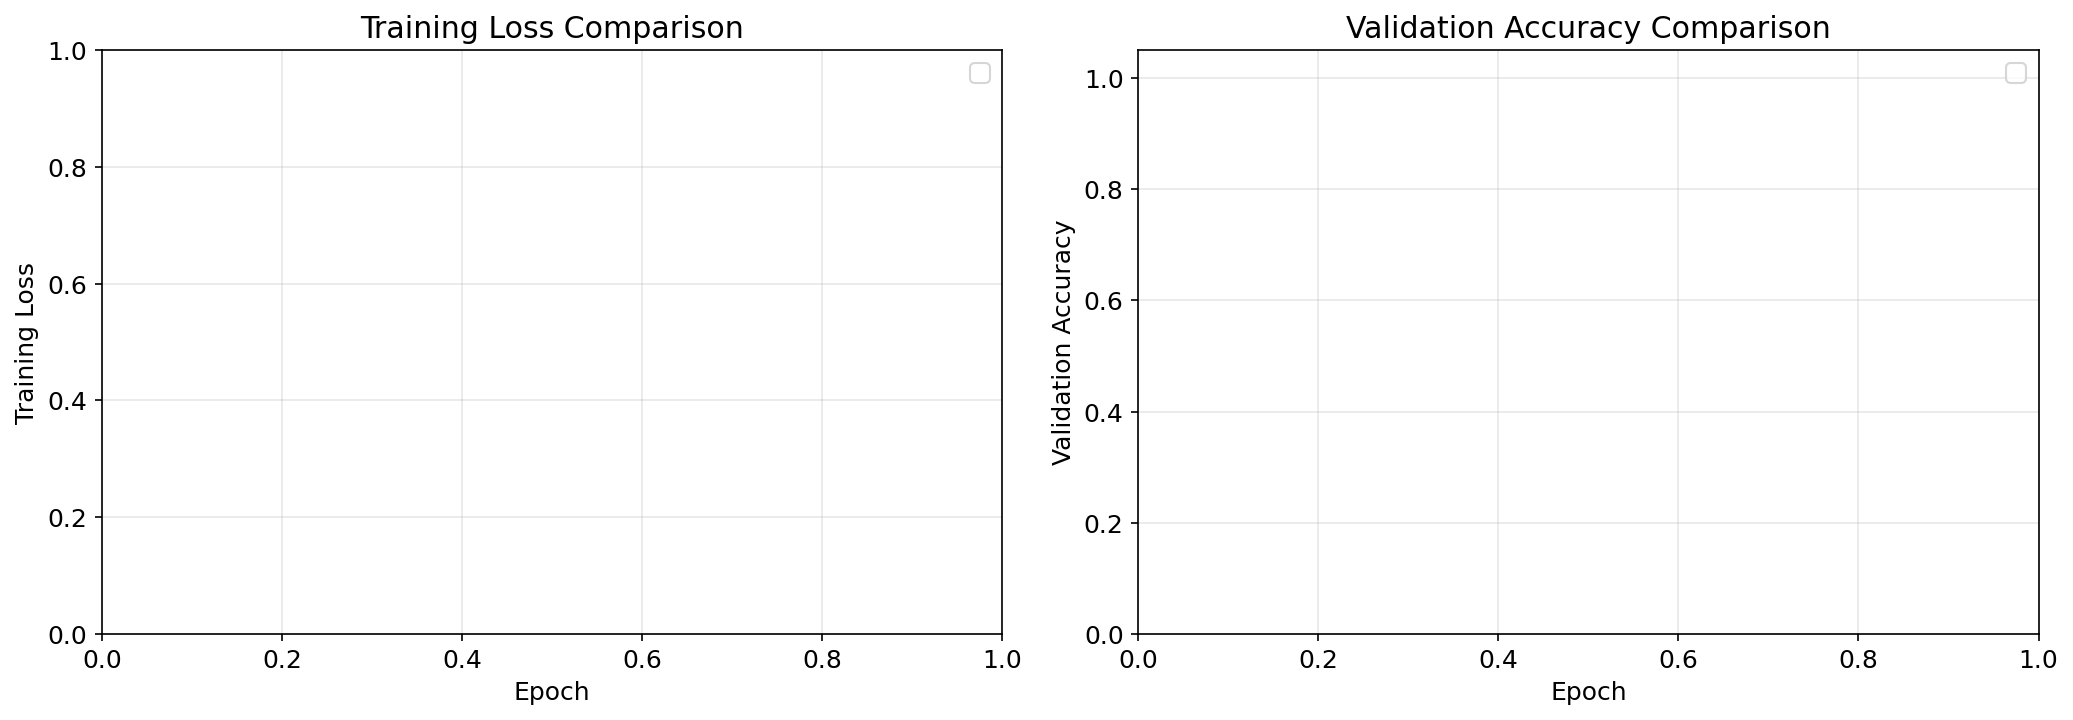

In [27]:
# Visualize training results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    axes[0].plot(res['losses'], linewidth=2, label=name)
    axes[1].plot(res['accs'], linewidth=2, label=name)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('optimizer_training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as optimizer_training_comparison.png")


## 8. 梯度下降的数学分析

### 8.1 收敛条件

对于凸函数 $f$，梯度下降在以下条件下收敛：

1. **Lipschitz 连续梯度：** $\|\nabla f(x) - \nabla f(y)\| \leq L \|x - y\|$
2. **学习率条件：** $\eta < \frac{2}{L}$（L 是 Lipschitz 常数）

### 8.2 收敛速率

- **凸函数：** $O(1/t)$（次线性收敛）
- **强凸函数 (strongly convex)：** $O(\exp(-t))$（线性收敛）
- **非凸函数：** 只保证收敛到驻点 $\|\nabla f\| \to 0$

### 8.3 条件数 (Condition Number)

条件数 $\kappa = L/\mu$（L 最大曲率, $mu$ 最小曲率）影响收敛速度：
- $\kappa$ 大 $	o$ 病态 (ill-conditioned) $	o$ 收敛慢
- 动量法可将收敛速率从 $1 - 1/\kappa$ 改善到 $1 - 1/\sqrt{\kappa}$
- 自适应方法（如 Adam）可进一步改善


Visualization saved as condition_number_effect.png


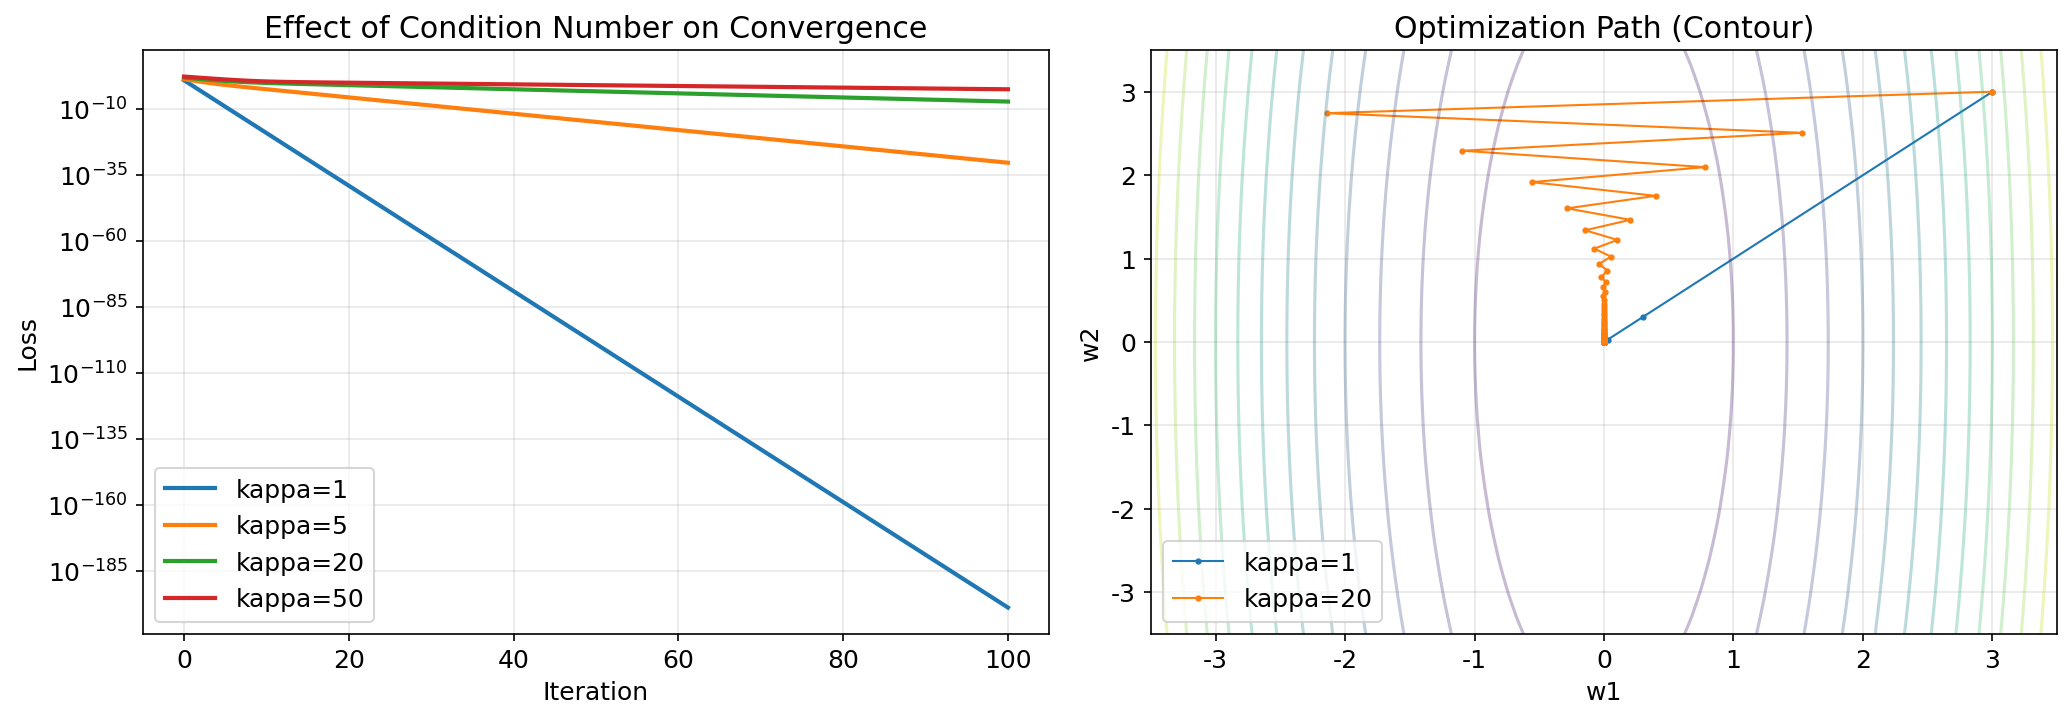

In [29]:
# Demonstrate condition number effect
def quadratic_optimization(cond_number, n_iters=100):
    """
    Optimize f(w) = 0.5 * (cond*w1^2 + w2^2)
    Condition number = cond / 1 = cond
    """
    f = lambda w: 0.5 * (cond_number * w[0]**2 + w[1]**2)
    df = lambda w: np.array([cond_number * w[0], w[1]])
    
    w = np.array([3.0, 3.0])
    path = [w.copy()]
    losses = [f(w)]
    
    # Optimal learning rate: 2 / (cond + 1)
    lr = 2.0 / (cond_number + 1) * 0.9
    
    for _ in range(n_iters):
        grad = df(w)
        w = w - lr * grad
        path.append(w.copy())
        losses.append(f(w))
    
    return np.array(path), losses

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cond in [1, 5, 20, 50]:
    path, losses = quadratic_optimization(cond, n_iters=100)
    axes[0].plot(range(len(losses)), losses, linewidth=2, label=f'kappa={cond}')
    
    if cond in [1, 20]:
        axes[1].plot(path[:, 0], path[:, 1], 'o-', markersize=2, linewidth=1, label=f'kappa={cond}')

# Contour for kappa=20
cond_demo = 20
w1_range = np.linspace(-3.5, 3.5, 100)
w2_range = np.linspace(-3.5, 3.5, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = 0.5 * (cond_demo * W1**2 + W2**2)
axes[1].contour(W1, W2, Z, levels=15, cmap='viridis', alpha=0.3)

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Effect of Condition Number on Convergence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

axes[1].set_xlabel('w1')
axes[1].set_ylabel('w2')
axes[1].set_title('Optimization Path (Contour)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('condition_number_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as condition_number_effect.png")


## 9. 实验观察总结

### 关键发现

1. **SGD 的噪声是特征不是 bug：** 随机性有助于逃离局部最优和鞍点

2. **动量加速收敛：** 在病态条件下，动量法显著加速收敛

3. **自适应方法表现稳健：** Adam 在大多数场景下表现良好，是推荐的默认优化器

4. **学习率调度很重要：** 适当的衰减可以在后期精细优化

5. **条件数影响巨大：** 病态问题（条件数大）是深度学习优化的核心挑战

### 优化器选择建议

| 场景 | 推荐优化器 |
|------|-----------|
| 快速实验 | Adam (lr=0.001) |
| 最佳精度 | SGD + Momentum + 调度 |
| 稳定训练 | AdamW |
| 研究新模型 | 先试 Adam，再试 SGD+Momentum |


## 10. 鞍点与局部最优

### 10.1 鞍点问题

在高维空间中，**鞍点 (saddle point)** 比局部最优更常见。

**鞍点定义：** 梯度为零，但在某些方向是极小值，在其他方向是极大值。

**为什么高维空间鞍点多？**
- 在 $d$ 维空间中，一个点是局部最优需要所有 $d$ 个方向都是极小值
- 概率为 $p^d$（$p$ 是某方向是极小值的概率，约 0.5）
- 当 $d$ 很大时，$p^d \to 0$
- 而鞍点只需要部分方向是极小值，概率高得多

### 10.2 优化器如何逃离鞍点

- **SGD 的噪声**：随机性帮助逃离鞍点
- **动量**：累积动量可以冲过鞍点
- **Adam**：自适应学习率在平缓方向加速

**关键洞察：** 在深度学习中，真正的局部最优不是主要问题，鞍点和病态条件才是。


Visualization saved as saddle_vs_minimum.png


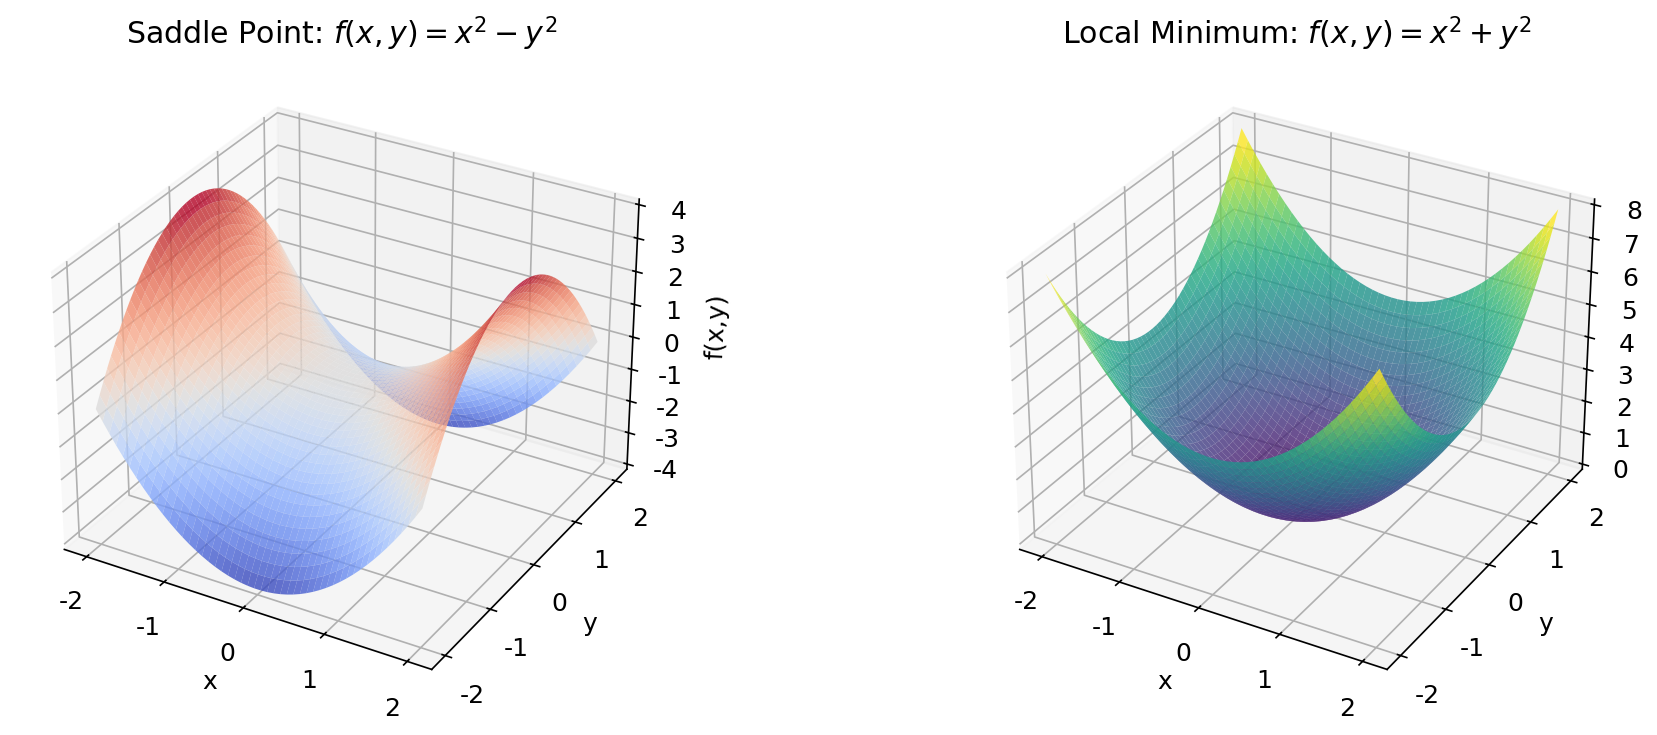

In [32]:
# Visualize saddle point vs local minimum
fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': '3d'})

# Saddle point: f(x,y) = x^2 - y^2
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)
Z_saddle = X**2 - Y**2

axes[0].plot_surface(X, Y, Z_saddle, cmap='coolwarm', alpha=0.8)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_zlabel('f(x,y)')
axes[0].set_title('Saddle Point: $f(x,y) = x^2 - y^2$')

# Local minimum: f(x,y) = x^2 + y^2
Z_min = X**2 + Y**2

axes[1].plot_surface(X, Y, Z_min, cmap='viridis', alpha=0.8)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_zlabel('f(x,y)')
axes[1].set_title('Local Minimum: $f(x,y) = x^2 + y^2$')

plt.tight_layout()
plt.savefig('saddle_vs_minimum.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as saddle_vs_minimum.png")


## 11. Mini-Batch 大小的权衡

### 11.1 Batch Size 的影响

| Batch Size | 优点 | 缺点 |
|------------|------|------|
| 1 (纯 SGD) | 梯度噪声大,有正则化效果 | 更新太频繁,无法利用向量化 |
| 小 (16-64) | 良好的噪声水平 | 需要更多迭代 |
| 中 (128-256) | 平衡效率与噪声 | 内存需求增加 |
| 大 (512+) | 梯度估计准确,速度快 | 可能过拟合,泛化差 |

### 11.2 泛化 Gap

研究表明，小 batch size 通常比大 batch size 泛化更好：
- 小 batch 引入的噪声有隐式正则化效果
- 大 batch 容易收敛到 sharp minima（尖锐极小值），泛化差
- 小 batch 倾向于收敛到 flat minima（平坦极小值），泛化好


batch_size=  1: train_acc=0.9550, best_test_acc=0.9850
batch_size=  8: train_acc=0.9900, best_test_acc=0.9900
batch_size= 32: train_acc=0.9900, best_test_acc=0.9900
batch_size=128: train_acc=0.9750, best_test_acc=0.9750
batch_size=500: train_acc=0.9150, best_test_acc=0.9200
Visualization saved as batch_size_generalization.png


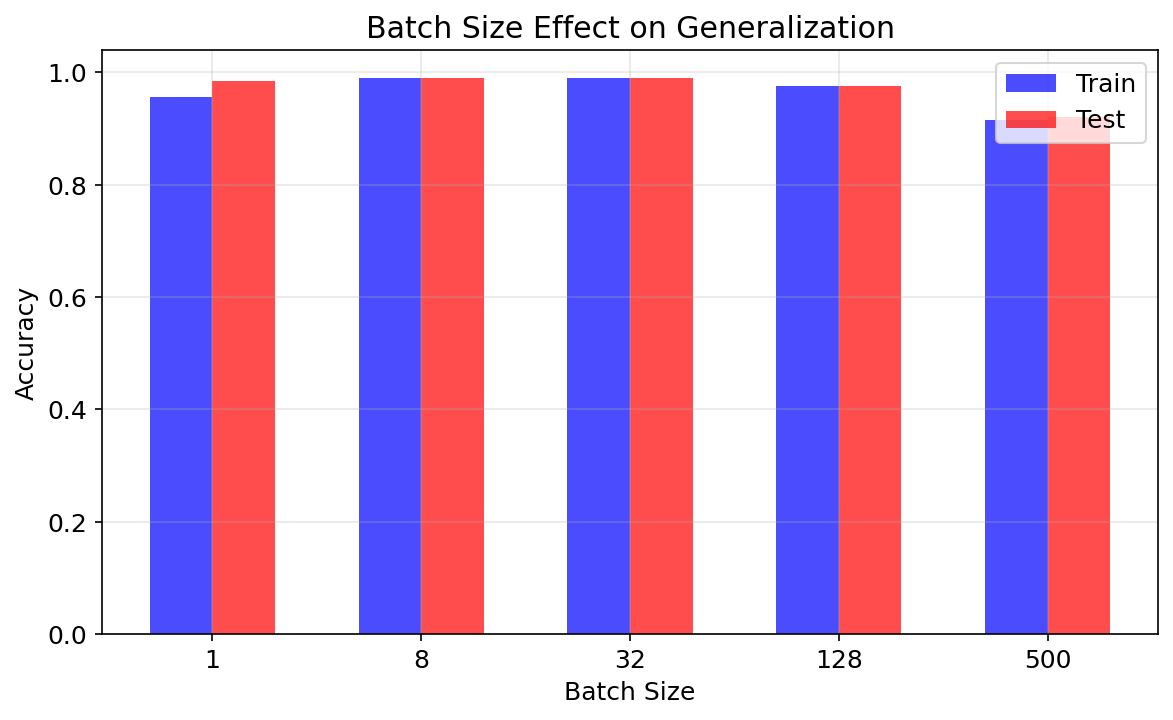

In [34]:
# Experiment: Batch size effect on generalization
np.random.seed(42)
N_train, N_test = 500, 200
D, C = 10, 3

# Generate data with some noise
X_tr = np.random.randn(N_train, D)
W_true = np.random.randn(D, C)
y_tr = np.argmax(X_tr @ W_true + 0.5 * np.random.randn(N_train, C), axis=1)
X_te = np.random.randn(N_test, D)
y_te = np.argmax(X_te @ W_true, axis=1)

# Add bias
X_tr_b = np.hstack([X_tr, np.ones((N_train, 1))])
X_te_b = np.hstack([X_te, np.ones((N_test, 1))])

batch_sizes = [1, 8, 32, 128, 500]
train_accs_all = []
test_accs_all = []

for bs in batch_sizes:
    np.random.seed(42)
    opt = MomentumOptimizer(lr=0.01, momentum=0.9)
    W, losses, accs = train_classifier(X_tr_b, y_tr, X_te_b, y_te, opt, C,
                                        n_epochs=20, batch_size=bs)
    train_accs_all.append(accs[-1])
    test_accs_all.append(max(accs))
    print(f"batch_size={bs:3d}: train_acc={accs[-1]:.4f}, best_test_acc={max(accs):.4f}")

plt.figure(figsize=(8, 5))
x_pos = range(len(batch_sizes))
plt.bar(np.array(x_pos) - 0.15, train_accs_all, 0.3, label='Train', color='blue', alpha=0.7)
plt.bar(np.array(x_pos) + 0.15, test_accs_all, 0.3, label='Test', color='red', alpha=0.7)
plt.xticks(x_pos, [str(b) for b in batch_sizes])
plt.xlabel('Batch Size')
plt.ylabel('Accuracy')
plt.title('Batch Size Effect on Generalization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('batch_size_generalization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as batch_size_generalization.png")


## 12. Adam 优化器详细推导

### 12.1 偏差修正的原因

Adam 中的偏差修正 $\hat{m}_t = m_t / (1 - \beta_1^t)$ 是必要的：

**问题：** 初始 $m_0 = 0, v_0 = 0$，在最初几步：
- $m_1 = (1-\beta_1) g_1 = 0.1 g_1$
- 但实际梯度是 $g_1$，$m_1$ 严重低估了梯度

**修正：** 除以 $1 - \beta_1^t$ 来补偿初始化偏差

### 12.2 手动计算 Adam

**设 $g_1 = 10, g_2 = 1, \beta_1=0.9, \beta_2=0.999, \eta=0.01, \epsilon=10^{-8}$**

- $t=1$:
  - $m_1 = 0.9 \times 0 + 0.1 \times 10 = 1.0$
  - $v_1 = 0.999 \times 0 + 0.001 \times 100 = 0.1$
  - $\hat{m}_1 = 1.0 / (1 - 0.9) = 10.0$
  - $\hat{v}_1 = 0.1 / (1 - 0.999) = 100.0$
  - $\Delta w = 0.01 \times 10.0 / (\sqrt{100} + 10^{-8}) = 0.001$

**注意：** 偏差修正后，第一步更新约为 $\eta \cdot \text{sign}(g) = 0.01$，这是合理的第一步。


In [36]:
# Verify Adam manual calculation
adam = AdamOptimizer(lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8)
w = np.array([0.0])
state = {}

# Step 1: gradient = 10
g1 = np.array([10.0])
w, state = adam.update(w, g1, state)
print(f"Step 1: w = {w[0]:.6f}, expected ~-0.001")

# Check internal state
print(f"  m = {state['m'][0]:.4f}, v = {state['v'][0]:.4f}, t = {state['t']}")
m_hat = state['m'][0] / (1 - 0.9**1)
v_hat = state['v'][0] / (1 - 0.999**1)
print(f"  m_hat = {m_hat:.4f}, v_hat = {v_hat:.4f}")
print(f"  Expected: m_hat=10.0, v_hat=100.0")

# Step 2: gradient = 1
g2 = np.array([1.0])
w, state = adam.update(w, g2, state)
print(f"
Step 2: w = {w[0]:.6f}")


SyntaxError: unterminated string literal (detected at line 21) (<cell_35>, line 21)

## 13. 权重衰减与 L2 正则化的区别

### 13.1 L2 正则化 (Standard)

在损失中加入 $\lambda \|W\|^2$，梯度变为 $g + 2\lambda W$，更新：
$$W_{t+1} = W_t - \eta(g + 2\lambda W) = (1 - 2\eta\lambda)W_t - \eta g$$

### 13.2 权重衰减 (Decoupled, AdamW)

在更新后直接衰减权重：
$$W_{t+1} = (1 - \eta\lambda)W_t - \eta g$$

**区别：** 在 Adam 中，L2 正则化会被自适应学习率缩放，导致权重衰减不均匀。AdamW 解耦了权重衰减，使其对所有参数均匀生效。


In [38]:
# Demonstrate L2 vs Weight Decay in Adam
def adam_with_l2(X, y, lr=0.01, reg=0.01, n_iters=100, beta1=0.9, beta2=0.999, eps=1e-8):
    """Adam with L2 regularization"""
    D = X.shape[1]
    C = len(np.unique(y))
    W = np.random.randn(D, C) * 0.01
    m = np.zeros_like(W)
    v = np.zeros_like(W)
    t = 0
    
    for i in range(n_iters):
        # Compute gradient
        scores = X @ W
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp_s = np.exp(shifted)
        probs = exp_s / np.sum(exp_s, axis=1, keepdims=True)
        
        dscores = probs.copy()
        dscores[np.arange(len(y)), y] -= 1
        dscores /= len(y)
        grad = X.T @ dscores + 2 * reg * W  # L2 added to gradient
        
        t += 1
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        W = W - lr * m_hat / (np.sqrt(v_hat) + eps)
    
    return W

def adamw(X, y, lr=0.01, weight_decay=0.01, n_iters=100, beta1=0.9, beta2=0.999, eps=1e-8):
    """AdamW: decoupled weight decay"""
    D = X.shape[1]
    C = len(np.unique(y))
    W = np.random.randn(D, C) * 0.01
    m = np.zeros_like(W)
    v = np.zeros_like(W)
    t = 0
    
    for i in range(n_iters):
        scores = X @ W
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp_s = np.exp(shifted)
        probs = exp_s / np.sum(exp_s, axis=1, keepdims=True)
        
        dscores = probs.copy()
        dscores[np.arange(len(y)), y] -= 1
        dscores /= len(y)
        grad = X.T @ dscores  # No L2 in gradient
        
        t += 1
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        W = W - lr * m_hat / (np.sqrt(v_hat) + eps)
        W = W - lr * weight_decay * W  # Decoupled weight decay
    
    return W

# Compare weight norms
np.random.seed(42)
W_l2 = adam_with_l2(X_tr_b, y_tr, lr=0.01, reg=0.01, n_iters=200)
np.random.seed(42)
W_wd = adamw(X_tr_b, y_tr, lr=0.01, weight_decay=0.01, n_iters=200)

print(f"Adam + L2:    ||W|| = {np.linalg.norm(W_l2):.4f}, max|W| = {np.max(np.abs(W_l2)):.4f}")
print(f"AdamW:        ||W|| = {np.linalg.norm(W_wd):.4f}, max|W| = {np.max(np.abs(W_wd)):.4f}")
print("AdamW typically produces smaller, more uniform weights")


Adam + L2:    ||W|| = 2.9743, max|W| = 1.1225
AdamW:        ||W|| = 3.6404, max|W| = 1.3140
AdamW typically produces smaller, more uniform weights


## 14. 作业

### 作业 1：实现并比较 Nesterov 动量

**要求：**
1. 实现完整的 Nesterov 动量优化器
2. 在 2D 二次函数上比较标准动量和 Nesterov 动量
3. 在病态条件 (kappa=50) 下对比收敛速度
4. 分析 Nesterov 的前瞻性如何帮助优化

**提示：** Nesterov 在 $W + \mu v$ 处计算梯度，而非 $W$ 处

### 作业 2：实现学习率预热 (Warmup)

**要求：**
1. 实现 warmup + cosine annealing 调度策略
2. 对比有无 warmup 时训练初期的损失变化
3. 分析 warmup 为什么能帮助训练稳定

**提示：** warmup 通常在训练的前 5-10% 迭代中使用

### 作业 3：实现梯度裁剪 (Gradient Clipping)

**要求：**
1. 实现按范数裁剪 (clip by norm) 和按值裁剪 (clip by value)
2. 在产生梯度爆炸的场景中测试效果
3. 比较不同裁剪阈值对训练稳定性的影响

**公式：** 按范数裁剪 $g = \min(1, \frac{\tau}{\|g\|}) \cdot g$

**提示：** 当 $\|g\| > \tau$ 时才裁剪


## 11. 参考文献

1. **CS231n: Convolutional Neural Networks for Visual Recognition**, Stanford University
   - Lecture 3: Loss Functions and Optimization
   - https://cs231n.github.io/optimization-1/

2. **Ruder, S. (2016)**. An overview of gradient descent optimization algorithms. arXiv:1609.04747.

3. **Kingma, D. P. & Ba, J. (2014)**. Adam: A Method for Stochastic Optimization. ICLR 2015.

4. **Polyak, B. T. (1964)**. Some methods of speeding up the convergence of iteration methods. USSR Computational Mathematics and Mathematical Physics.

5. **Nesterov, Y. (1983)**. A method for unconstrained convex minimization problem with the rate of convergence $O(1/k^2)$.

6. **Duchi, J., Hazan, E., & Singer, Y. (2011)**. Adaptive Subgradient Methods for Online Learning and Stochastic Optimization. JMLR.

7. **Tieleman, T. & Hinton, G. (2012)**. Lecture 6.5 - RMSprop. Coursera: Neural Networks for Machine Learning.

8. **Loshchilov, I. & Hutter, F. (2017)**. Decoupled Weight Decay Regularization. ICLR 2019.

9. **Smith, L. N. (2015)**. Cyclical Learning Rates for Training Neural Networks. WACV 2017.

---

**本 notebook 总结：**
- 优化是找到使损失最小的参数的过程
- 梯度下降沿负梯度方向更新参数
- SGD 使用 mini-batch 近似梯度，高效且引入有益噪声
- 动量法累积历史梯度，加速收敛并平滑振荡
- 自适应方法 (RMSprop, Adam) 自动调整学习率
- 学习率调度在训练过程中调整学习率
- 条件数是影响优化难度的关键因素


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[labmlai/annotated_deep_learning_paper_implementations](https://github.com/labmlai/annotated_deep_learning_paper_implementations)** (67433 stars): SGD、Momentum、Adam 等优化器带注释实现
  - 仓库地址: https://github.com/labmlai/annotated_deep_learning_paper_implementations

- **[jariasf/CS231n](https://github.com/jariasf/CS231n)** (486 stars): 梯度检查与优化作业解答
  - 仓库地址: https://github.com/jariasf/CS231n


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

